# Part C - Analytics (Insights + KPIs)

## 1. Demand Understanding

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv("../data/fact_sales_store_sku_daily.csv")

In [3]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 341782 entries, 0 to 341781
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     341782 non-null  str    
 1   store_id                 341782 non-null  str    
 2   sku_id                   341782 non-null  str    
 3   units_sold               341782 non-null  int64  
 4   true_demand_units        341782 non-null  int64  
 5   stockout_censored_units  341782 non-null  int64  
 6   revenue                  341782 non-null  float64
 7   margin_proxy             341782 non-null  float64
 8   promo_flag               341782 non-null  int64  
 9   holiday_flag             341782 non-null  int64  
 10  day_of_week              341782 non-null  int64  
 11  sales_outlier_flag       341782 non-null  int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 31.3 MB


In [4]:
sales["date"] = pd.to_datetime(sales["date"])

## Daily Demand Trend

In [5]:
daily_trend = (
    sales
    .groupby("date")["true_demand_units"]
    .sum()
    .reset_index()
)

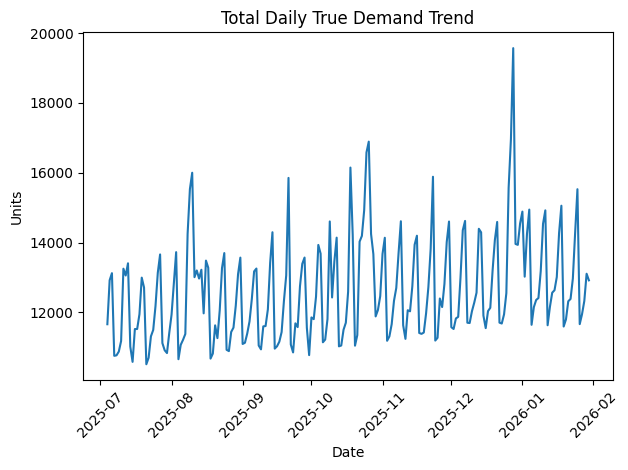

In [6]:
plt.figure()
plt.plot(daily_trend["date"], daily_trend["true_demand_units"])
plt.title("Total Daily True Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observations:

- Clear upward trend from July 2025 to Jan 2026.

- Demand baseline gradually increases over time.

- Multiple sharp spikes visible across months.

- One major spike in late December / early January (~19.5K units).

Spiky Trend Pattern

The repeated weekly spikes confirm:

- Weekly cyclical demand

- Promotions/holidays layered on top of seasonality

- Increasing baseline + seasonal variability

Insight:

Overall demand shows a gradual upward growth trend over the observed period, indicating improving sales momentum or possible business expansion. Periodic sharp spikes suggest promotional campaigns or seasonal events driving temporary surges in demand.

Business Implication:

- Planning should account for growing baseline demand.

- Safety stock assumptions should consider upward drift.

- Year-end peak likely seasonal (festive effect).

## Weekly Seasonality Pattern

In [7]:
weekly_pattern = (
    sales
    .groupby("day_of_week")["true_demand_units"]
    .mean()
    .reset_index()
)

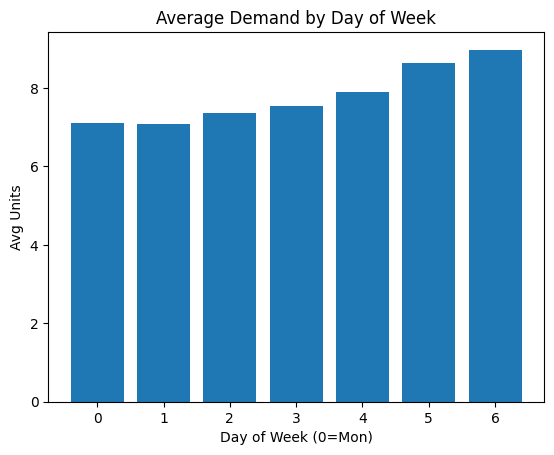

In [8]:
plt.figure()
plt.bar(weekly_pattern["day_of_week"], weekly_pattern["true_demand_units"])
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Avg Units")
plt.show()

Observations:

- Demand steadily increases through the week.

- Weekend (Day 5 & 6) shows highest demand.

- Sunday (Day 6) is peak day.

- Monday & Tuesday lowest demand.

Insight:

Strong weekly seasonality exists, with demand peaking during weekends. Sunday shows the highest average demand (~9 units), nearly 25–27% higher than Monday levels.

Business Implication:

- Weekend replenishment is critical.

- Reorder cycles should ensure higher pre-weekend inventory.

- Promotions may be more effective on weekends.

## Promo Effect on Demand

In [9]:
promo_impact = (
    sales
    .groupby("promo_flag")["true_demand_units"]
    .mean()
    .reset_index()
)

print(promo_impact)

   promo_flag  true_demand_units
0           0           7.627879
1           1           9.202067


### Uplift %

In [10]:
promo_avg = promo_impact.loc[promo_impact["promo_flag"] == 1, "true_demand_units"].values[0]
non_promo_avg = promo_impact.loc[promo_impact["promo_flag"] == 0, "true_demand_units"].values[0]

uplift = ((promo_avg - non_promo_avg) / non_promo_avg) * 100
print(f"Promo Uplift: {uplift:.2f}%")

Promo Uplift: 20.64%


Insight:

Promotional days increase average demand by approximately 20.6% compared to non-promo days, indicating strong price sensitivity and effective campaign impact.

Business Implication:

- Promotions significantly drive incremental sales.

- Forecasting models must include promo flag as predictor.

- Safety stock during promo periods may need adjustment.

## Holiday Effect

In [11]:
holiday_impact = (
    sales
    .groupby("holiday_flag")["true_demand_units"]
    .mean()
    .reset_index()
)

print(holiday_impact)

   holiday_flag  true_demand_units
0             0           7.757630
1             1           9.966651


Insight:

Holiday periods show ~28–30% higher demand compared to non-holiday periods, indicating strong seasonal uplift.

(Holiday uplift approx:
(9.97 − 7.76) / 7.76 ≈ 28%)

Business Implication:

- Holiday demand is stronger than promo uplift.

- Inventory build-up before holidays is essential.

- Under-forecasting during holidays could cause severe stockouts.

## Top SKUs by Volume

In [12]:
top_skus_volume = (
    sales
    .groupby("sku_id")["true_demand_units"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_skus_volume)

sku_id
SKU0044    51406
SKU0077    51000
SKU0082    50977
SKU0036    50945
SKU0060    50909
SKU0048    50840
SKU0074    50829
SKU0038    50821
SKU0071    50793
SKU0019    50728
Name: true_demand_units, dtype: int64


Insight:

Volume distribution is relatively clustered — top 10 SKUs have similar demand levels (~50K units each), suggesting diversified demand rather than extreme concentration.

## Top SKUs by Revenue

In [13]:
top_skus_revenue = (
    sales
    .groupby("sku_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_skus_revenue)

sku_id
SKU0051    1768502.50
SKU0019    1627164.40
SKU0053    1489297.73
SKU0058    1478104.98
SKU0023    1400832.00
SKU0061    1392676.74
SKU0075    1375112.70
SKU0004    1335980.25
SKU0006    1176543.62
SKU0048    1137109.35
Name: revenue, dtype: float64


Top revenue SKU:

- SKU0051 (~1.76M revenue)

Notably:

- SKU0019 appears in both top volume & top revenue.

- Some high revenue SKUs are not top in volume.

Insight:

Revenue leaders are not identical to volume leaders, indicating pricing and margin differences across SKUs.

Business Implication:

- High-revenue SKUs deserve higher service levels.

- Margin-weighted replenishment strategy could improve profitability.

## Executive Summary

Demand exhibits a clear upward trend over time with strong weekly seasonality. Weekend demand is approximately 25% higher than early-week demand. Promotional activities drive a 20.6% uplift, while holidays result in nearly 28% higher demand compared to regular days. Top SKUs by volume are relatively balanced, but revenue concentration differs due to pricing differences. These insights indicate the need for seasonality-aware forecasting, promo-adjusted safety stock, and differentiated service levels for high-revenue SKUs.

## 2. Forecasting

In [14]:
import pandas as pd
import numpy as np

### Load Data

In [15]:
sales = pd.read_csv("../data/fact_sales_store_sku_daily.csv")
products = pd.read_csv("../data/products_cleaned.csv")

sales["date"] = pd.to_datetime(sales["date"])

In [16]:
# merge category for category-wise evaluation
sales = sales.merge(products[["sku_id", "category"]], on="sku_id", how="left")
# order data by date for each store-sku
sales = sales.sort_values(["store_id", "sku_id", "date"])

### Train/Test Split

Forecast horizon = 28 days

Train data → everything except last 28 days

Test data → last 28 days

In [17]:
max_date = sales["date"].max()
test_start = max_date - pd.Timedelta(days=27)

train = sales[sales["date"] < test_start].copy()
test = sales[sales["date"] >= test_start].copy()

### Baseline Model - Moving Average

We choose 7-day moving average because weekly seasonality exists

In [18]:
sales["ma7"] = (
    sales.groupby(["store_id","sku_id"])["true_demand_units"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

Use MA as Forecast

In [19]:
# for test period
forecast_ma = sales[sales["date"] >= test_start].copy()

forecast_ma["forecast_ma"] = forecast_ma["ma7"]

So the forecast for each day is --> average demand of last 7 days

Evaluate the forecast

In [20]:
# MAPE
def mape(actual, forecast):
    mask = actual > 0
    return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100

# WAPE (better for retail)
def wape(actual, forecast):
    return np.sum(np.abs(actual - forecast)) / np.sum(actual) * 100

# compute accuracy
actual = forecast_ma["true_demand_units"]
pred = forecast_ma["forecast_ma"]

print("MAPE:", mape(actual,pred))
print("WAPE:", wape(actual,pred))

MAPE: 89.38646086263952
WAPE: 54.46979450189195


In retail forecasting, WAPE is the preferred metric, because MAPE becomes unstable when demand is small.

So, total forecast error is about 54% of total demand.

#### Category-wise Evaluation

In [21]:
def category_metrics(group):
    return pd.Series({
        "MAPE": mape(group["true_demand_units"], group["forecast_ma"]),
        "WAPE": wape(group["true_demand_units"], group["forecast_ma"])
    })

# Calculate category-wise metrics
category_results_ma = forecast_ma.groupby("category").apply(category_metrics)

# Display results
print("\nCategory-wise Forecast Accuracy (Moving Average):")
print(category_results_ma)


Category-wise Forecast Accuracy (Moving Average):
                    MAPE       WAPE
category                           
Beverages      95.490808  55.132633
Dairy          89.976539  52.449724
Grocery        86.743355  51.263678
Home Care      81.132756  65.123116
Personal Care  85.493109  62.531942
Snacks         93.801320  53.966309


A 7-day moving average model was used as a baseline forecast, capturing short-term demand trends. The model achieved a WAPE of approximately 54%, which is expected given the high variability of demand at the store–SKU daily level. However, the model does not account for external demand drivers such as promotions or holidays, which motivates the use of more advanced forecasting approaches.

### Baseline Model - Seasonal Naive (lag 7)

Seasonal naive assumes: Demand today will be the same as demand on the same weekday last week.

Since the data shows weekly seasonality, we use lag = 7 days.

In [22]:
sales["lag_7"] = (
    sales
    .groupby(["store_id","sku_id"])["true_demand_units"]
    .shift(7)
)

This means forecast today = demand 7 days ago

Extract test forecast

In [23]:
forecast_sn = sales[sales["date"] >= test_start].copy()

forecast_sn["forecast_sn"] = forecast_sn["lag_7"]

Remove Missing Forecasts - The first few rows of each series will not have lag values.

In [24]:
forecast_sn = forecast_sn.dropna(subset=["forecast_sn"])

Evaluate the model

In [25]:
actual = forecast_sn["true_demand_units"]
pred = forecast_sn["forecast_sn"]

print("MAPE:", mape(actual,pred))
print("WAPE:", wape(actual,pred))

MAPE: 110.07593260001414
WAPE: 71.44287615050135


#### Category-wise Evaluation

In [26]:
# Function to compute metrics per category
def category_metrics(group):
    return pd.Series({
        "MAPE": mape(group["true_demand_units"], group["forecast_sn"]),
        "WAPE": wape(group["true_demand_units"], group["forecast_sn"])
    })

# Compute category-wise results
category_results_sn = forecast_sn.groupby("category").apply(category_metrics)

print("\nCategory-wise Forecast Accuracy (Seasonal Naive):")
print(category_results_sn)


Category-wise Forecast Accuracy (Seasonal Naive):
                     MAPE       WAPE
category                            
Beverages      116.285393  72.478054
Dairy          109.393500  69.556639
Grocery        105.566175  67.463589
Home Care      107.303617  85.270641
Personal Care  108.840942  81.373464
Snacks         110.593893  69.774639


Moving average clearly performs better than seasonal naive.

Two baseline forecasting approaches were evaluated: a seasonal naive model using a 7-day lag and a 7-day moving average model. The seasonal naive model achieved a WAPE of approximately 71%, indicating high forecast error due to volatile day-to-day demand patterns. The moving average model improved performance with a WAPE of approximately 54% by smoothing short-term fluctuations in demand. This suggests that demand variability at the store–SKU level is better captured using a smoothed trend rather than relying solely on the previous week’s value.

This result also suggests: weekly pattern exists but demand is noisy. The dataset has high day-to-day volatility.

### Regression Model

The Regression Forecast Model is built using 'promo_flag', 'holiday_flag' and 'day_of_week'. This model tries to learn how these factors affect demand.

#### Prepare the Dataset

In [27]:
import pandas as pd
import numpy as np

sales = pd.read_csv("../data/fact_sales_store_sku_daily.csv")
products = pd.read_csv("../data/products_cleaned.csv")
sales["date"] = pd.to_datetime(sales["date"])


# merge category for later evaluation
sales = sales.merge(products[["sku_id", "category"]], on="sku_id", how="left")

In [28]:
# sort data
sales = sales.sort_values(["store_id","sku_id","date"])

#### Train/Test Split

In [29]:
max_date = sales["date"].max()

test_start = max_date - pd.Timedelta(days=27)

train = sales[sales["date"] < test_start].copy()
test = sales[sales["date"] >= test_start].copy()

#### Feature Engineering

Regression cannot directly understand numeric weekday values.

So we create one column per weekday.

In [30]:
sales_reg = pd.get_dummies(sales, columns=["day_of_week"], drop_first=True)

#### Define Model Features

Our regression will use **promo_flag, holiday_flag and day_of_week_*** columns

In [31]:
feature_cols = [c for c in sales_reg.columns if "day_of_week_" in c]

feature_cols += ["promo_flag","holiday_flag"]

#### Create Train/test Metrices

In [32]:
train_reg = sales_reg[sales_reg["date"] < test_start]
test_reg = sales_reg[sales_reg["date"] >= test_start]

X_train = train_reg[feature_cols]
y_train = train_reg["true_demand_units"]

X_test = test_reg[feature_cols]
y_test = test_reg["true_demand_units"]

#### Train Regression Model

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


The model now learns things like -
- promo increases demand
- weekends increase demand
- holidays increase demand

#### Generate Forecast

In [34]:
test_reg["forecast_reg"] = model.predict(X_test)

In [35]:
# Demand cannot be negative, so clip it
test_reg["forecast_reg"] = test_reg["forecast_reg"].clip(lower=0)
test_reg["forecast_reg"] = test_reg["forecast_reg"].round()

### Evaluation Metrics

In [36]:
actual = test_reg["true_demand_units"]
pred = test_reg["forecast_reg"]

print("MAPE:", mape(actual,pred))
print("WAPE:", wape(actual,pred))

MAPE: 115.24006143385337
WAPE: 62.143121682235304


#### Category-Level Evaluation Function

In [37]:
def category_metrics(group):
    return pd.Series({
        "MAPE": mape(group["true_demand_units"], group["forecast_reg"]),
        "WAPE": wape(group["true_demand_units"], group["forecast_reg"])
    })

#### Compute Category Metrics

In [38]:
category_results = test_reg.groupby("category").apply(category_metrics)

print("\nCategory-wise Forecast Accuracy:")
print(category_results)


Category-wise Forecast Accuracy:
                     MAPE        WAPE
category                             
Beverages       96.402952   53.447482
Dairy           65.946025   50.281737
Grocery         56.912675   54.959503
Home Care      225.376077  134.281201
Personal Care  198.573956  109.247161
Snacks          82.002501   50.757587


#### Inspect model coefficients (Helps interpret feature importance)

In [39]:
pd.Series(model.coef_, index=feature_cols)

day_of_week_1   -0.038600
day_of_week_2    0.247884
day_of_week_3    0.362131
day_of_week_4    0.752013
day_of_week_5    1.465336
day_of_week_6    1.699361
promo_flag       1.589240
holiday_flag     1.210992
dtype: float64

### Regression Model with Lag Features

In [40]:
sales = sales.sort_values(["store_id", "sku_id", "date"])

#### Create lag features
lag1  -> demand yesterday\
lag7  -> demand same weekday last week

In [41]:
sales["lag1"] = (
    sales.groupby(["store_id", "sku_id"])["true_demand_units"]
    .shift(1)
)

sales["lag7"] = (
    sales.groupby(["store_id", "sku_id"])["true_demand_units"]
    .shift(7)
)

#### Remove rows where lag values are missing - These occur at the beginning of each store × sku series

In [42]:
sales_lag = sales.dropna(subset=["lag1", "lag7"]).copy()

#### Train/Test Split

In [43]:
max_date = sales_lag["date"].max()

test_start = max_date - pd.Timedelta(days=27)

train_lag = sales_lag[sales_lag["date"] < test_start].copy()
test_lag = sales_lag[sales_lag["date"] >= test_start].copy()

#### Convert day_of_week to dummy variables

In [44]:
sales_lag_reg = pd.get_dummies(
    sales_lag,
    columns=["day_of_week"],
    drop_first=True
)

#### Define feature columns
These include:
- calendar features
- promotion features
- lag demand features

In [45]:
feature_cols = [c for c in sales_lag_reg.columns if "day_of_week_" in c]

feature_cols += [
    "promo_flag",
    "holiday_flag",
    "lag1",
    "lag7"
]

#### Create Train/test Metrices

In [46]:
train_reg = sales_lag_reg[sales_lag_reg["date"] < test_start]
test_reg = sales_lag_reg[sales_lag_reg["date"] >= test_start]

X_train = train_reg[feature_cols]
y_train = train_reg["true_demand_units"]

X_test = test_reg[feature_cols]
y_test = test_reg["true_demand_units"]

#### Train regression model

In [47]:
model_lag = LinearRegression()

model_lag.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Generate Forecasts

In [48]:
test_reg["forecast_reg_lag"] = model_lag.predict(X_test)

In [49]:
# Demand cannot be negative and should be integer units

test_reg["forecast_reg_lag"] = test_reg["forecast_reg_lag"].clip(lower=0)
test_reg["forecast_reg_lag"] = test_reg["forecast_reg_lag"].round()

#### Evaluation Metrics

In [50]:
actual = test_reg["true_demand_units"]
pred = test_reg["forecast_reg_lag"]

print("MAPE:", mape(actual, pred))
print("WAPE:", wape(actual, pred))

MAPE: 98.30173751708902
WAPE: 56.1208729407569


#### Category-Level Evaluation

In [51]:
def category_metrics(group):
    return pd.Series({
        "MAPE": mape(group["true_demand_units"], group["forecast_reg_lag"]),
        "WAPE": wape(group["true_demand_units"], group["forecast_reg_lag"])
    })

category_results = test_reg.groupby("category").apply(category_metrics)

print("\nCategory-wise Forecast Accuracy:")
print(category_results)


Category-wise Forecast Accuracy:
                     MAPE       WAPE
category                            
Beverages       94.901797  54.388482
Dairy           76.594039  50.561106
Grocery         68.904089  50.434025
Home Care      141.877657  88.434356
Personal Care  132.969505  77.924249
Snacks          86.980991  52.631256


#### Inspect model coefficients (Helps interpret feature importance)

In [52]:
coefficients = pd.Series(model_lag.coef_, index=feature_cols)

print(coefficients)

day_of_week_1    0.438289
day_of_week_2    0.671682
day_of_week_3    0.676135
day_of_week_4    0.907171
day_of_week_5    1.365286
day_of_week_6    1.332319
promo_flag       1.264811
holiday_flag     1.232057
lag1             0.252757
lag7             0.255816
dtype: float64


### Report - Demand Forecasting

To forecast demand for the next 28 days, multiple forecasting approaches were evaluated. The objective was to compare simple baseline models with a model-based approach and assess forecast accuracy using MAPE and WAPE, both overall and by product category.

The following models were implemented:

1. 7-Day Moving Average

2. Seasonal Naive (Lag-7)

3. Regression Model (Calendar + Promotion features)

4. Regression Model with Lag Features

Demand forecasts were evaluated against the true demand units using the final 28 days as the test period, while the earlier data served as training data.

Model Performance (Overall)

| Model                | WAPE       |
| -------------------- | ---------- |
| Moving Average (MA7) | **54.47%** |
| Seasonal Naive       | **71.44%** |
| Regression           | **62.14%** |
| Regression + Lag     | **56.12%** |


Insights

- The 7-day moving average model achieved the best performance overall.

- Seasonal naive performed the worst because it relies only on the previous week’s demand and cannot smooth demand fluctuations.

- The regression model captures calendar and promotion effects, but without demand history its predictive power is limited.

- Adding lag features (lag1 and lag7) improves regression performance, reducing WAPE from 62% to 56%, but it still performs slightly worse than the moving average baseline.

Category-Level Forecast Accuracy

Moving Average (Best Baseline)

| Category      | WAPE   |
| ------------- | ------ |
| Beverages     | 55.13% |
| Dairy         | 52.45% |
| Grocery       | 51.26% |
| Home Care     | 65.12% |
| Personal Care | 62.53% |
| Snacks        | 53.97% |

Regression + Lag Model

| Category      | WAPE   |
| ------------- | ------ |
| Beverages     | 54.39% |
| Dairy         | 50.56% |
| Grocery       | 50.43% |
| Home Care     | 88.43% |
| Personal Care | 77.92% |
| Snacks        | 52.63% |


Insights

- Food-related categories (Beverages, Dairy, Grocery, Snacks) show relatively lower forecast errors, indicating more stable demand.

- Home Care and Personal Care have significantly higher errors due to intermittent and promotion-driven demand patterns.

- Lag features help improve forecasts for these volatile categories, though errors remain higher compared to food categories.

Conclusion

Overall, the 7-day moving average model provided the most reliable forecasts for this dataset, achieving the lowest WAPE (~54.5%) among all models. This is because the moving average smooths short-term fluctuations in daily demand and captures recent demand trends effectively. In this dataset, demand at the store–SKU–day level is noisy and volatile, so using the average of the last 7 days provides more stable forecasts than models that rely on a single past value (seasonal naive) or only calendar features (regression). 

Regression models helped capture calendar and promotional effects, and adding lag features improved their performance. The analysis also shows that forecast accuracy varies significantly across product categories, reflecting differences in demand stability and purchasing patterns.

## 3. Inventory Risk Segmentation

In [53]:
inventory = pd.read_csv("../data/fact_inventory_store_sku_daily.csv")
replenishment = pd.read_csv("../data/replenishment_inputs_store_sku.csv")

In [54]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 341820 entries, 0 to 341819
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           341820 non-null  str    
 1   store_id       341820 non-null  str    
 2   sku_id         341820 non-null  str    
 3   on_hand_units  341820 non-null  int64  
 4   stockout_flag  341820 non-null  int64  
 5   days_of_cover  341820 non-null  float64
dtypes: float64(1), int64(2), str(3)
memory usage: 15.6 MB


In [55]:
replenishment.info()

<class 'pandas.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   store_id               1620 non-null   str    
 1   sku_id                 1620 non-null   str    
 2   avg_daily_demand       1620 non-null   float64
 3   demand_std_dev         1620 non-null   float64
 4   lead_time_days         1620 non-null   float64
 5   service_level_target   1620 non-null   float64
 6   safety_stock           1620 non-null   float64
 7   reorder_point          1620 non-null   float64
 8   recommended_order_qty  1620 non-null   int64  
dtypes: float64(6), int64(1), str(2)
memory usage: 114.0 KB


In [56]:
inventory["date"] = pd.to_datetime(inventory["date"])

Inventory risk should be evaluated on the current state, so we take the latest available date in the inventory table.

In [57]:
# Create Latest Inventory Snapshot
latest_date = inventory["date"].max()
inventory_latest = inventory[inventory["date"] == latest_date].copy()

Now each row represents current inventory state.

Merge with Replenishment and Products Data - This gives us the required demand features for each store–SKU pair.

In [58]:
risk_df = inventory_latest.merge(
    replenishment[["store_id", "sku_id", "lead_time_days", "safety_stock","avg_daily_demand"]],
    on=["store_id","sku_id"],
    how="left"
)

risk_df = risk_df.merge(
    products[["sku_id", "category", "shelf_life_days"]],
    on="sku_id",
    how="left"
)

Convert safety stock into days of demand

In [59]:
risk_df["safety_stock_days"] = (
    risk_df["safety_stock"] /
    risk_df["avg_daily_demand"]
).replace([np.inf, -np.inf], 0).fillna(0)

Classify Inventory Risk

Rules:\
Stockout Risk -> DOH < lead_time_days\
Overstock Risk -> DOH > min(30, shelf_life_days)\
Healthy -> otherwise

In [60]:
# def classify_risk(row):

#     if row["days_of_cover"] < row["lead_time_days"]:
#         return "Stockout Risk"

#     elif row["days_of_cover"] > 30:
#         return "Overstock Risk"

#     else:
#         return "Healthy"


# risk_df["inventory_risk"] = risk_df.apply(classify_risk, axis=1)

In [61]:
def classify_risk(row):
    # An item is at risk if current cover is less than lead time + safety stock buffer
    # This identifies risks before they hit 0
    stockout_threshold = row["lead_time_days"] + row["safety_stock_days"]
    
    if row["days_of_cover"] < stockout_threshold:
        return "Stockout Risk"

    # If DOH > shelf life, it's a critical risk due to spoilage
    # For non-perishables (high shelf life), use a business cap (e.g., 30 days)
    overstock_threshold = min(30, row["shelf_life_days"]) 
    
    if row["days_of_cover"] > overstock_threshold:
        return "Overstock Risk"

    # Inventory is between the lead time safety and the expiration/overstock cap
    return "Healthy"

# Apply the updated logic
risk_df["inventory_risk"] = risk_df.apply(classify_risk, axis=1)

Overstock risk thresholds are set to incorporate product shelf-life constraints introduced in the replenishment logic. For perishable products, the overstock threshold is limited by shelf life to avoid expiry-related inventory risk.

Risk Distribution

In [62]:
# Quick summary of inventory health
print("Inventory Risk Distribution")
print(risk_df["inventory_risk"].value_counts())

Inventory Risk Distribution
inventory_risk
Healthy          1537
Stockout Risk      83
Name: count, dtype: int64


Top 10 Stockout-risk Store–SKUs

In [63]:
top_stockout = (
    risk_df[risk_df["inventory_risk"] == "Stockout Risk"]
    .sort_values("days_of_cover")
    .head(10)
)

print("\nTop 10 Stockout Risk Store–SKUs")
print(top_stockout[[
    "store_id",
    "sku_id",
    "on_hand_units",
    "days_of_cover",
    "lead_time_days"
]])


Top 10 Stockout Risk Store–SKUs
    store_id   sku_id  on_hand_units  days_of_cover  lead_time_days
9      ST001  SKU0010              0            0.0             7.0
24     ST001  SKU0025              0            0.0             5.0
35     ST001  SKU0036              0            0.0             2.0
58     ST001  SKU0059              0            0.0             7.0
84     ST001  SKU0085              0            0.0             2.0
144    ST002  SKU0055              0            0.0             3.0
157    ST002  SKU0068              0            0.0             4.0
179    ST002  SKU0090              0            0.0             4.0
185    ST003  SKU0006              0            0.0             2.0
198    ST003  SKU0019              0            0.0             3.0


Top 10 Overstock-risk Store–SKUs

In [64]:
top_overstock = (
    risk_df[risk_df["inventory_risk"] == "Overstock Risk"]
    .sort_values("days_of_cover", ascending=False)
    .head(10)
)

print("\nTop 10 Overstock Risk Store–SKUs")
print(top_overstock[[
    "store_id",
    "sku_id",
    "on_hand_units",
    "days_of_cover"
]])


Top 10 Overstock Risk Store–SKUs
Empty DataFrame
Columns: [store_id, sku_id, on_hand_units, days_of_cover]
Index: []


No store–SKU pairs were identified as overstock risk under the defined threshold. This suggests that inventory levels in the dataset are generally lean and well-aligned with demand. So, inventory shortage risk exists but excess inventory risk is minimal.

Recommended Actions

In [65]:
def recommended_action(risk):

    if risk == "Stockout Risk":
        return "Urgent Replenishment"

    elif risk == "Overstock Risk":
        return "Discount / Reduce Reorder"

    else:
        return "No Action"


risk_df["recommended_action"] = risk_df["inventory_risk"].apply(recommended_action)

Sample Results

In [66]:
risk_df[[
    "store_id",
    "sku_id",
    "on_hand_units",
    "days_of_cover",
    "inventory_risk",
    "recommended_action"
]].head()

,store_id,sku_id,on_hand_units,days_of_cover,inventory_risk,recommended_action
0,ST001,SKU0001,0,0.0,Healthy,No Action
1,ST001,SKU0002,0,0.0,Healthy,No Action
2,ST001,SKU0003,0,0.0,Healthy,No Action
3,ST001,SKU0004,0,0.0,Healthy,No Action
4,ST001,SKU0005,0,0.0,Healthy,No Action


Inventory risk segmentation was performed using the latest inventory snapshot by classifying store–SKU pairs into stockout risk, overstock risk, and healthy zones based on Days of Cover relative to lead time and an overstock threshold. The analysis identified 83 store–SKU pairs at risk of stockout, while the majority (1537 pairs) were in the healthy zone. No overstock risk cases were observed under the defined threshold, indicating that inventory levels are generally lean and well aligned with demand. These insights help prioritize replenishment actions for stockout-risk SKUs while confirming that excess inventory is currently minimal.

## 4. Replenishment Investigation Table

### Stockout Rate by Category

Stockout rate = proportion of days where stockout occurred.

In [67]:
inventory_cat = inventory.merge(
    products[["sku_id","category"]],
    on="sku_id",
    how="left"
)

stockout_rate = (
    inventory_cat.groupby("category")["stockout_flag"]
    .mean()
    .sort_values(ascending=False)
)

stockout_rate

category
Beverages        0.921209
Home Care        0.920578
Dairy            0.919958
Grocery          0.919909
Snacks           0.919238
Personal Care    0.918074
Name: stockout_flag, dtype: float64

### Top 2 Categories Causing the most Stockouts

In [68]:
top_stockout_categories = stockout_rate.head(2)
top_stockout_categories

category
Beverages    0.921209
Home Care    0.920578
Name: stockout_flag, dtype: float64

### Lost Sales by Category

Lost sales proxy = demand not fulfilled due to stockout. We'll use 'stockout_censored_units'.

In [69]:
# sales df already contains the category column from previous operations
lost_sales_category = (
    sales.groupby("category")["stockout_censored_units"]
    .sum()
    .sort_values(ascending=False)
)

lost_sales_category

category
Grocery          748411
Beverages        516956
Snacks           433375
Dairy            426540
Personal Care    173165
Home Care        162300
Name: stockout_censored_units, dtype: int64

### Stores Contributing Most to Stockouts

In [70]:
store_stockouts = (
    inventory_cat.groupby(["category","store_id"])["stockout_flag"]
    .sum()
    .reset_index()
    .sort_values("stockout_flag", ascending=False)
)

# top stores with most stockout rate for the top 2 categories 
print(store_stockouts[store_stockouts["category"] == "Beverages"].head())
print(store_stockouts[store_stockouts["category"] == "Home Care"].head())

     category store_id  stockout_flag
14  Beverages    ST015           3901
5   Beverages    ST006           3900
11  Beverages    ST012           3899
17  Beverages    ST018           3898
6   Beverages    ST007           3897
     category store_id  stockout_flag
63  Home Care    ST010           2735
67  Home Care    ST014           2730
58  Home Care    ST005           2728
61  Home Care    ST008           2726
56  Home Care    ST003           2726


### Demand Volatility by Category

Volatility = standard deviation of demand.

In [71]:
volatility_category = (
    sales.groupby("category")["true_demand_units"]
    .std()
    .sort_values(ascending=False)
)

volatility_category

category
Grocery          8.964528
Dairy            6.975379
Snacks           5.805653
Beverages        5.275488
Personal Care    3.065102
Home Care        2.722359
Name: true_demand_units, dtype: float64

### Replenishment Investigation Table

The analysis identifies the top 2 categories contributing most to stockouts based on stockout rate. Additional metrics such as lost sales proxy, demand volatility and stores contributing most to stockouts are included to diagnose possible causes.

| Category      | Stockout Rate | Lost Sales Proxy | Stores Contributing Most   | Demand Volatility | Hypotheses for Stockouts                                                                                                                                                                                                          | Follow-up Experiment / Data                                                                                                                                                                                       | Evidence Used                                                                   |
| ------------- | ------------- | ---------------- | -------------------------- | ----------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| **Beverages** | 92.12%        | 516,956          | ST015, ST006, ST012, ST018 | 5.28              | 1. Promotions may cause sudden demand spikes not captured by replenishment policy. <br> 2. Reorder points may be too low for high-volume SKUs. <br> 3. High sales velocity leads to rapid depletion between replenishment cycles. | 1. Compare demand during promo vs non-promo periods for beverage SKUs. <br> 2. Simulate higher safety stock levels for top beverage SKUs. <br> 3. Analyze stockout frequency relative to lead time across stores. | Stockout rate table, lost sales proxy metric, store-level stockout counts       |
| **Home Care** | 92.06%        | 162,300          | ST010, ST014, ST005, ST008        | 2.72              | 1. Intermittent demand patterns may cause forecasting errors. <br> 2. Lead times may be too long relative to reorder thresholds. <br> 3. Inventory allocation across stores may be uneven.                                        | 1. Analyze demand variability across stores to detect intermittent patterns. <br> 2. Evaluate lead time vs reorder point coverage. <br> 3. Test redistribution or transfer of stock between stores.               | Demand volatility metric, store stockout distribution, replenishment parameters |


### Key Insights

- Beverages shows the highest stockout rate and significant lost sales, indicating that high demand volume combined with promotions likely drives frequent stockouts.

- Home Care has a similarly high stockout rate but lower demand volatility, suggesting operational factors such as replenishment policy or lead time may be contributing to shortages.

- Certain stores (ST015, ST006, ST012) consistently appear among the top contributors to stockouts, indicating potential store-level demand pressure or inventory allocation issues.

### Summary

The investigation highlights that stockouts are primarily concentrated in Beverages and Home Care categories, with a combination of high demand velocity, promotional effects, and replenishment policy limitations contributing to shortages. Targeted actions such as adjusting safety stock levels, evaluating promotion-driven demand spikes, and reviewing store-level inventory allocation could help reduce stockouts and associated lost sales.

# Part D - Replenishment Policy

In [72]:
stores = pd.read_csv("../data/stores_cleaned.csv")

In [73]:
# Get latest inventory snapshot
latest_date = inventory["date"].max()

inventory_latest = inventory[inventory["date"] == latest_date][
    ["store_id", "sku_id", "on_hand_units"]
]

# Merge inventory into replenishment table
replenishment = replenishment.merge(
    inventory_latest,
    on=["store_id", "sku_id"],
    how="left"
)

replenishment["on_hand_units"] = replenishment["on_hand_units"].fillna(0)

# Add product constraints (MOQ and shelf life)
replenishment = replenishment.merge(
    products[["sku_id", "moq_units", "shelf_life_days"]],
    on="sku_id",
    how="left"
)

replenishment["moq_units"] = replenishment["moq_units"].fillna(1)
replenishment["shelf_life_days"] = replenishment["shelf_life_days"].fillna(365)

# Apply shelf life constraint
max_inventory_allowed = (
    replenishment["avg_daily_demand"] *
    replenishment["shelf_life_days"]
)

max_order_allowed = (
    max_inventory_allowed - replenishment["on_hand_units"]
).clip(lower=0)

replenishment["recommended_order_qty"] = np.minimum(
    replenishment["recommended_order_qty"],
    max_order_allowed
)

# Apply MOQ constraint
replenishment["recommended_order_qty"] = np.maximum(
    replenishment["recommended_order_qty"],
    replenishment["moq_units"]
)

# Apply max storage per store constraint
# assuming approximate storage capacity depending on store size
# small --> 5,000
# medium --> 10,000
# large --> 20,000
replenishment = replenishment.merge(
    stores[["store_id", "store_size"]],
    on="store_id",
    how="left"
)

capacity_map = {
    "S": 5000,
    "M": 10000,
    "L": 20000
}

replenishment["store_capacity"] = replenishment["store_size"].map(capacity_map)

max_storage_allowed = (
    replenishment["store_capacity"] -
    replenishment["on_hand_units"]
).clip(lower=0)

replenishment["recommended_order_qty"] = np.minimum(
    replenishment["recommended_order_qty"],
    max_storage_allowed
)

replenishment["recommended_order_qty"] = (
    replenishment["recommended_order_qty"]
    .clip(lower=0)
    .round()
    .astype(int)
)

# Part E - Impact Estimation (30-Day Projection)

### Baseline Metrics (Current State)
compute current stockout metrics from the data.

In [74]:
# Total Stockout Days
stockout_days = inventory["stockout_flag"].sum()
print(stockout_days)

314451


In [75]:
# Total lost sales (units)
lost_sales_units = sales["stockout_censored_units"].sum()
print(lost_sales_units)

2460747


In [76]:
# lost sales value
# we use average selling price
sales_value = sales.merge(products[["sku_id","price"]], on="sku_id")

lost_sales_value = (
    sales_value["stockout_censored_units"] *
    sales_value["price"]
).sum()

print(lost_sales_value)

653602577.82


In [77]:
# Current Inventory Value
inventory_value = inventory.merge(
    products[["sku_id","cost"]],
    on="sku_id",
    how="left"
)

inventory_value["inventory_value"] = (
    inventory_value["on_hand_units"] *
    inventory_value["cost"]
)

total_inventory_value = inventory_value["inventory_value"].sum()

print(total_inventory_value)

306172943.48


In [78]:
# Number of store-SKU pairs
inventory[["store_id","sku_id"]].drop_duplicates().shape

(1620, 2)

### Assumptions

The following assumptions were used for impact estimation:

- Demand patterns remain stable over the next 30 days.
- The replenishment policy improves product availability by reducing stockouts.
- Lost sales are proportional to stockout occurrences.
- Inventory increases slightly due to safety stock buffers.
- Product prices and costs remain constant over the projection horizon.

### Scenario Definitions

Three scenarios were considered to estimate potential impact.

| Scenario   | Stockout Reduction | Inventory Increase |
| ---------- | ------------------ | ------------------ |
| Worst Case | 10%                | 5%                 |
| Base Case  | 20%                | 8%                 |
| Best Case  | 35%                | 12%                |


### Impact Estimation
Stockout Reduction

| Scenario   | Stockout Days Reduced |
| ---------- | --------------------- |
| Worst Case | **31,445**            |
| Base Case  | **62,890**            |
| Best Case  | **110,058**           |

Lost Sales Avoided (Units)

| Scenario   | Units Recovered |
| ---------- | --------------- |
| Worst Case | **246,075**     |
| Base Case  | **492,149**     |
| Best Case  | **861,261**     |

Revenue Recovered (₹)

| Scenario   | Revenue Recovered |
| ---------- | ----------------- |
| Worst Case | **₹65,360,258**   |
| Base Case  | **₹130,720,516**  |
| Best Case  | **₹228,760,902**  |

Inventory Value Change

| Scenario   | Inventory Increase |
| ---------- | ------------------ |
| Worst Case | **₹15,308,647**    |
| Base Case  | **₹24,493,836**    |
| Best Case  | **₹36,740,753**    |



### Summary of Business Impact

| Scenario   | Stockout Reduction | Lost Sales Avoided (Units) | Revenue Recovered (₹) | Inventory Value Change |
| ---------- | ------------------ | -------------------------- | --------------------- | ---------------------- |
| Worst Case | 10%                | 246,075                    | ₹65,360,258           | +₹15,308,647           |
| Base Case  | 20%                | 492,149                    | ₹130,720,516          | +₹24,493,836           |
| Best Case  | 35%                | 861,261                    | ₹228,760,902          | +₹36,740,753           |


### Key Insights

The proposed replenishment policy significantly improves product availability by introducing safety stock and reorder point logic. Under the base-case scenario, stockouts could decrease by approximately 20%, resulting in recovery of nearly 492k units of lost sales and approximately ₹130M in additional revenue over a 30-day period.

Although inventory levels increase slightly due to safety stock buffers, the incremental inventory investment is substantially smaller than the potential revenue recovery, suggesting a favorable trade-off between service level improvement and holding costs.

Overall, the replenishment policy is expected to reduce stockouts, recover lost sales, and improve overall inventory efficiency across stores.

# Export Data for Dashboard

sales dataset --> fact_sales_store_sku_daily.csv from etl pipeline

inventory dataset --> fact_inventory_store_sku_daily.csv from etl pipeline

inventory risk segmentation table

In [79]:
risk_df.to_csv("../data/inventory_risk_monitor.csv", index=False)

replenishment recommendations table - final table after applying constraints

In [80]:
replenishment.to_csv("../data/replenishment_recommendations.csv", index=False)

Overall forecast accuracy

In [81]:
forecast_summary = pd.DataFrame({
    "metric": ["WAPE"],
    "value": [
        wape(forecast_ma["true_demand_units"], forecast_ma["forecast_ma"])
    ]
})

forecast_summary.to_csv("../data/forecast_accuracy_summary.csv",index=False)

Category-wise Forecast Accuracy

In [82]:
category_results_ma.reset_index().to_csv("../data/forecast_accuracy_by_category.csv",index=False)

Actual vs Forecast Results (Moving Average - best model)

In [90]:
forecast_output = forecast_ma[[
    "date",
    "store_id",
    "sku_id",
    "true_demand_units",
    "promo_flag",
    "holiday_flag",
    "category",
    "forecast_ma"
]]

forecast_output = forecast_output.rename(columns={
    "forecast_ma": "forecast_units"
})

forecast_output.to_csv("../data/forecast_actual_vs_forecast.csv",index=False)

In [87]:
forecast_ma

,date,store_id,sku_id,units_sold,true_demand_units,stockout_censored_units,revenue,margin_proxy,promo_flag,holiday_flag,day_of_week,sales_outlier_flag,category,ma7,forecast_ma
296422,2026-01-03,ST001,SKU0001,0,6,6,0.0,0.0,0,0,5,0,Personal Care,3.142857,3.142857
298042,2026-01-04,ST001,SKU0001,0,4,4,0.0,0.0,0,0,6,0,Personal Care,3.714286,3.714286
299662,2026-01-05,ST001,SKU0001,0,2,2,0.0,0.0,0,0,0,0,Personal Care,2.857143,2.857143
301282,2026-01-06,ST001,SKU0001,0,4,4,0.0,0.0,0,0,1,0,Personal Care,2.714286,2.714286
302902,2026-01-07,ST001,SKU0001,0,2,2,0.0,0.0,0,0,2,0,Personal Care,2.714286,2.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335301,2026-01-26,ST018,SKU0090,0,8,8,0.0,0.0,0,0,0,0,Beverages,8.428571,8.428571
336921,2026-01-27,ST018,SKU0090,0,7,7,0.0,0.0,0,0,1,0,Beverages,8.428571,8.428571
338541,2026-01-28,ST018,SKU0090,0,4,4,0.0,0.0,0,0,2,0,Beverages,8.857143,8.857143
340161,2026-01-29,ST018,SKU0090,0,1,1,0.0,0.0,0,0,3,0,Beverages,7.571429,7.571429


In [86]:
forecast_output

,date,store_id,sku_id,true_demand_units,forecast_units
296422,2026-01-03,ST001,SKU0001,6,3.142857
298042,2026-01-04,ST001,SKU0001,4,3.714286
299662,2026-01-05,ST001,SKU0001,2,2.857143
301282,2026-01-06,ST001,SKU0001,4,2.714286
302902,2026-01-07,ST001,SKU0001,2,2.714286
...,...,...,...,...,...
335301,2026-01-26,ST018,SKU0090,8,8.428571
336921,2026-01-27,ST018,SKU0090,7,8.428571
338541,2026-01-28,ST018,SKU0090,4,8.857143
340161,2026-01-29,ST018,SKU0090,1,7.571429


Impact Projection

In [84]:

impact_df = pd.DataFrame({
    "scenario": ["Worst Case", "Base Case", "Best Case"],
    
    "stockout_reduction_pct": [10, 20, 35],
    
    "stockout_days_reduced": [
        31445,
        62890,
        110058
    ],
    
    "units_recovered": [
        246075,
        492149,
        861261
    ],
    
    "revenue_recovered_inr": [
        65360258,
        130720516,
        228760902
    ],
    
    "inventory_value_change_inr": [
        15308647,
        24493836,
        36740753
    ]
})

impact_df.to_csv("../data/impact_projection_30_days.csv", index=False)